In [ ]:
from analyzer import * 
from utils.corr import *  
from utils.plot_corr import *   
import seaborn as sns 
sns.set_style('whitegrid') 

/home/work/.anaconda/envs/privacyovod_new_copy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# MMStar 

In [2]:
mm = MMStarResults()
# answers_pivot = mm.combine_mh(model_acc=mm.model_mc) 
md = mm.model_blind 
md = md[(md['finetuned'] == 'Pretrained') & (md['condition'] == 'inst blind')] 
pids = mm.human.participant_id.unique()    
md.finetuned.unique()  , md.model.unique() 

13 7
[]


(array(['Pretrained'], dtype=object),
 array(['InternVL 3.5 (1B)', 'InternVL 3.5 (2B)', 'InternVL 3.5 (4B)',
        'InternVL 3.5 (8B)', 'Qwen3‑VL (2B)', 'Qwen3‑VL (4B)',
        'Qwen3‑VL (8B)', 'LLaVA‑Mistral (7B)', 'Qwen3 (8B)',
        'LLaVA‑1.5 (7B)', 'Qwen3 (4B)', 'LLaVA‑Vicuna (7B)'], dtype=object))

In [6]:
md.condition.unique()

array(['inst blind'], dtype=object)

In [18]:
mm.human['answer_raw'], mm.human['answer_normalized']

(0       2
 1       2
 2       2
 4       1
 5       1
        ..
 5603    3
 5604    1
 5605    1
 5606    2
 5607    2
 Name: answer_raw, Length: 4938, dtype: object,
 0       B
 1       B
 2       B
 4       A
 5       A
        ..
 5603    C
 5604    A
 5605    A
 5606    B
 5607    B
 Name: answer_normalized, Length: 4938, dtype: object)

In [19]:
mh = mm.human.rename(columns={'answer_normalized': 'extracted_choice'})

In [94]:
res_HH

{'title': 'Human-Human correct',
 'metric': 'spearman',
 'mean_r': 0.12316440882790562,
 'ci_2p5': 0.08473671169967369,
 'ci_97p5': 0.16159210595613754,
 'n_pairs': 20,
 'corr_mat':                                   0756a860_20251124_133827  \
 0756a860_20251124_133827                               NaN   
 02f952bb_20251210_230336                          0.148621   
 14d2420f_20251208_150302                          0.182519   
 29127478_20251202_100107                          0.068598   
 218b2db5_20251126_084136                          0.051216   
 3238ebaf_20251126_140604                          0.065570   
 3a36e078_20251205_225238                          0.092346   
 5d843d39_20251127_141921                          0.112319   
 60de6bd6_20251210_170035                          0.027148   
 6b3a1a8d_20251125_135446                          0.113377   
 73df43f3_20251204_210431                          0.049137   
 74d408e5_20251213_134035                          0.117950   


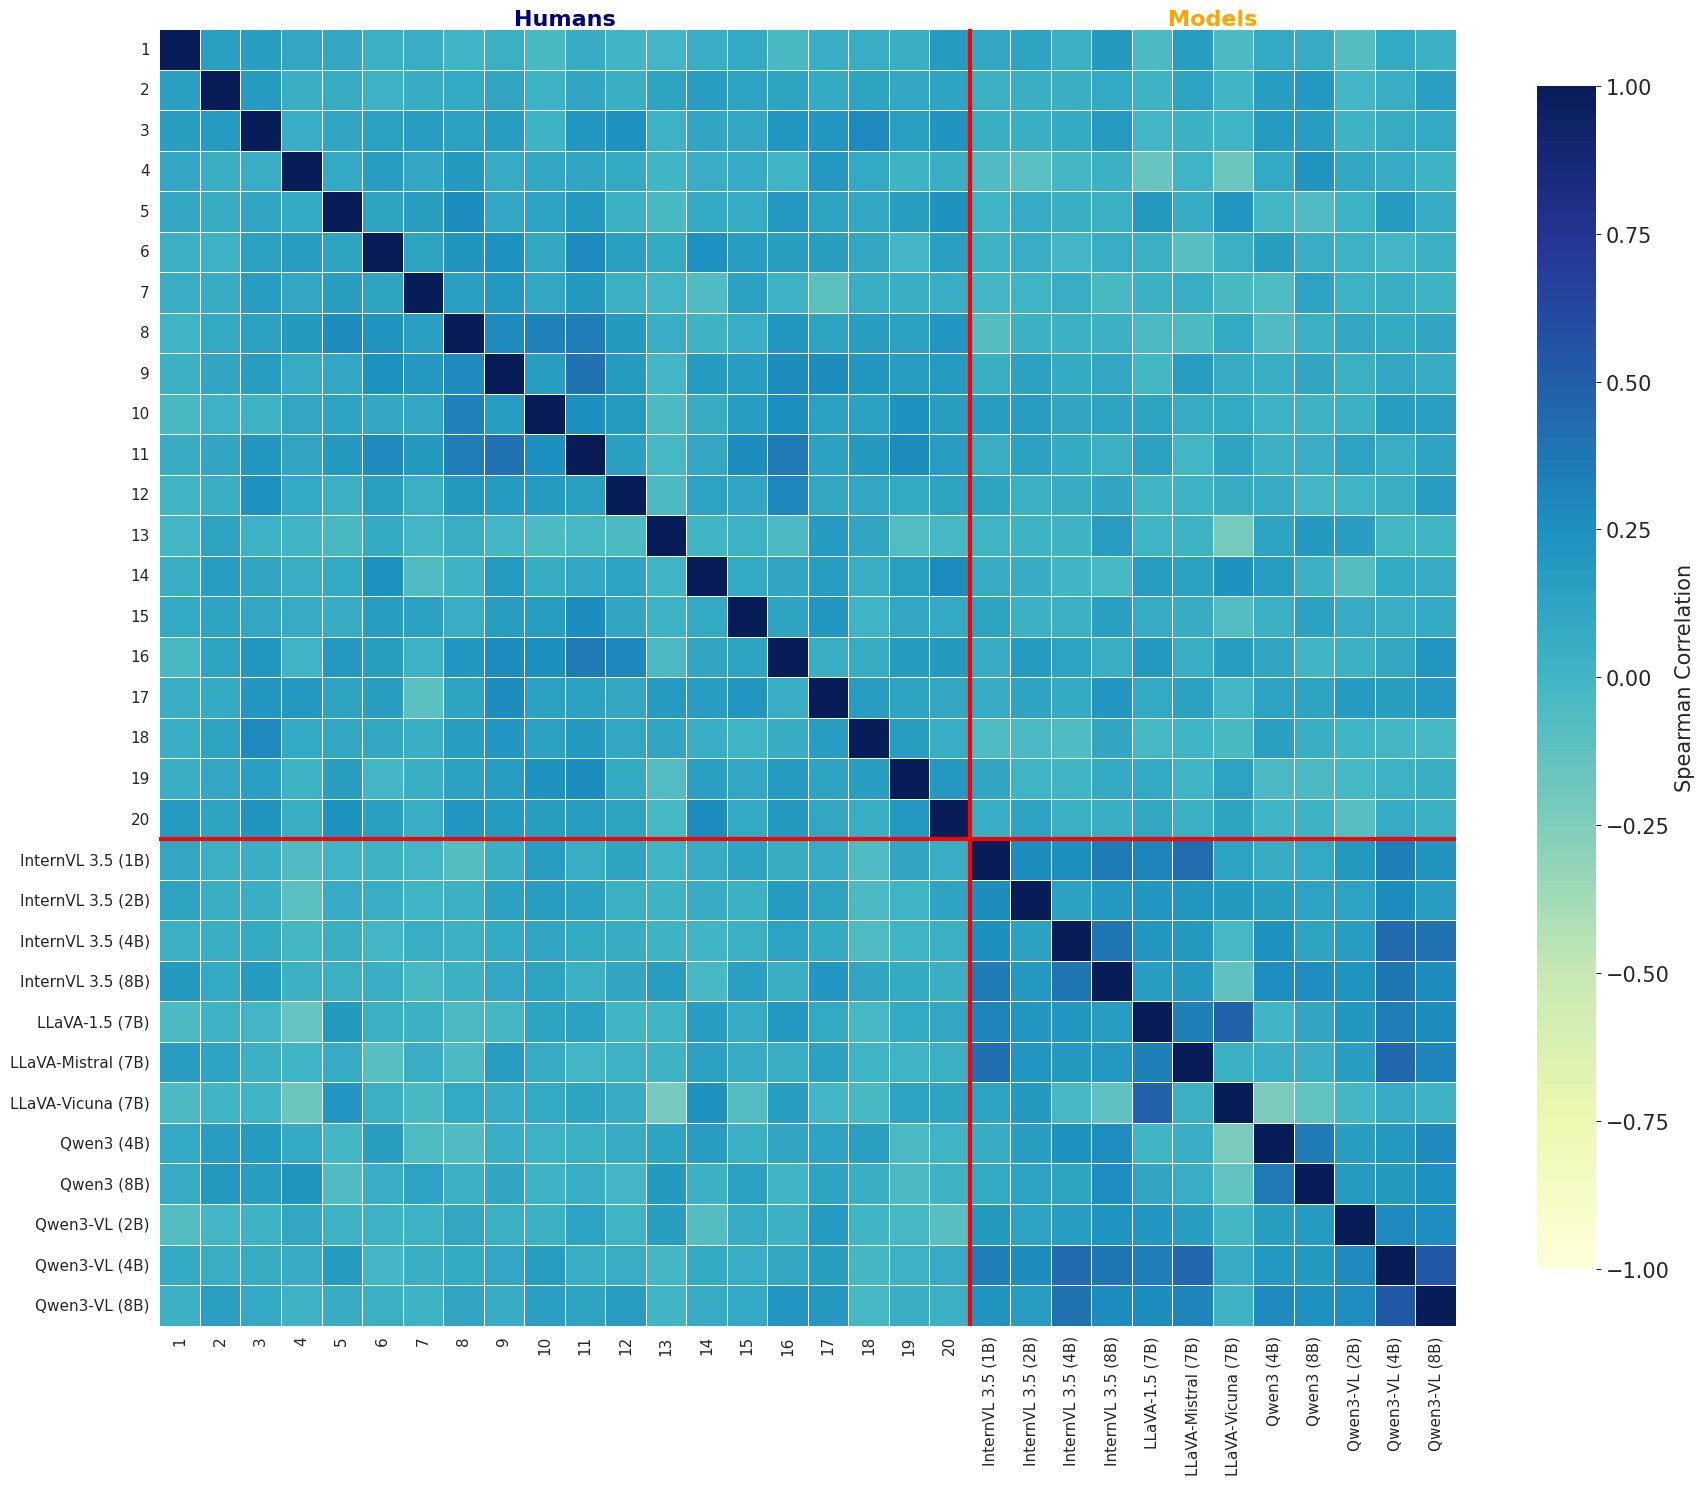

In [93]:
res_HH, llm, model_corr, res_HM, res_MM = get_corr(
    mh, md, pids, correlation_type='spearman', metrics="correct", n_boot=0
)  
combined_matrix, participant_mapping = plot_correlation_heatmap(
    res_HH['corr_mat'], llm['corr_mat'], res_HM, res_MM,
    test_subjects=pids,
    save_path='mmstar_spearman_heatmap.png'
)  

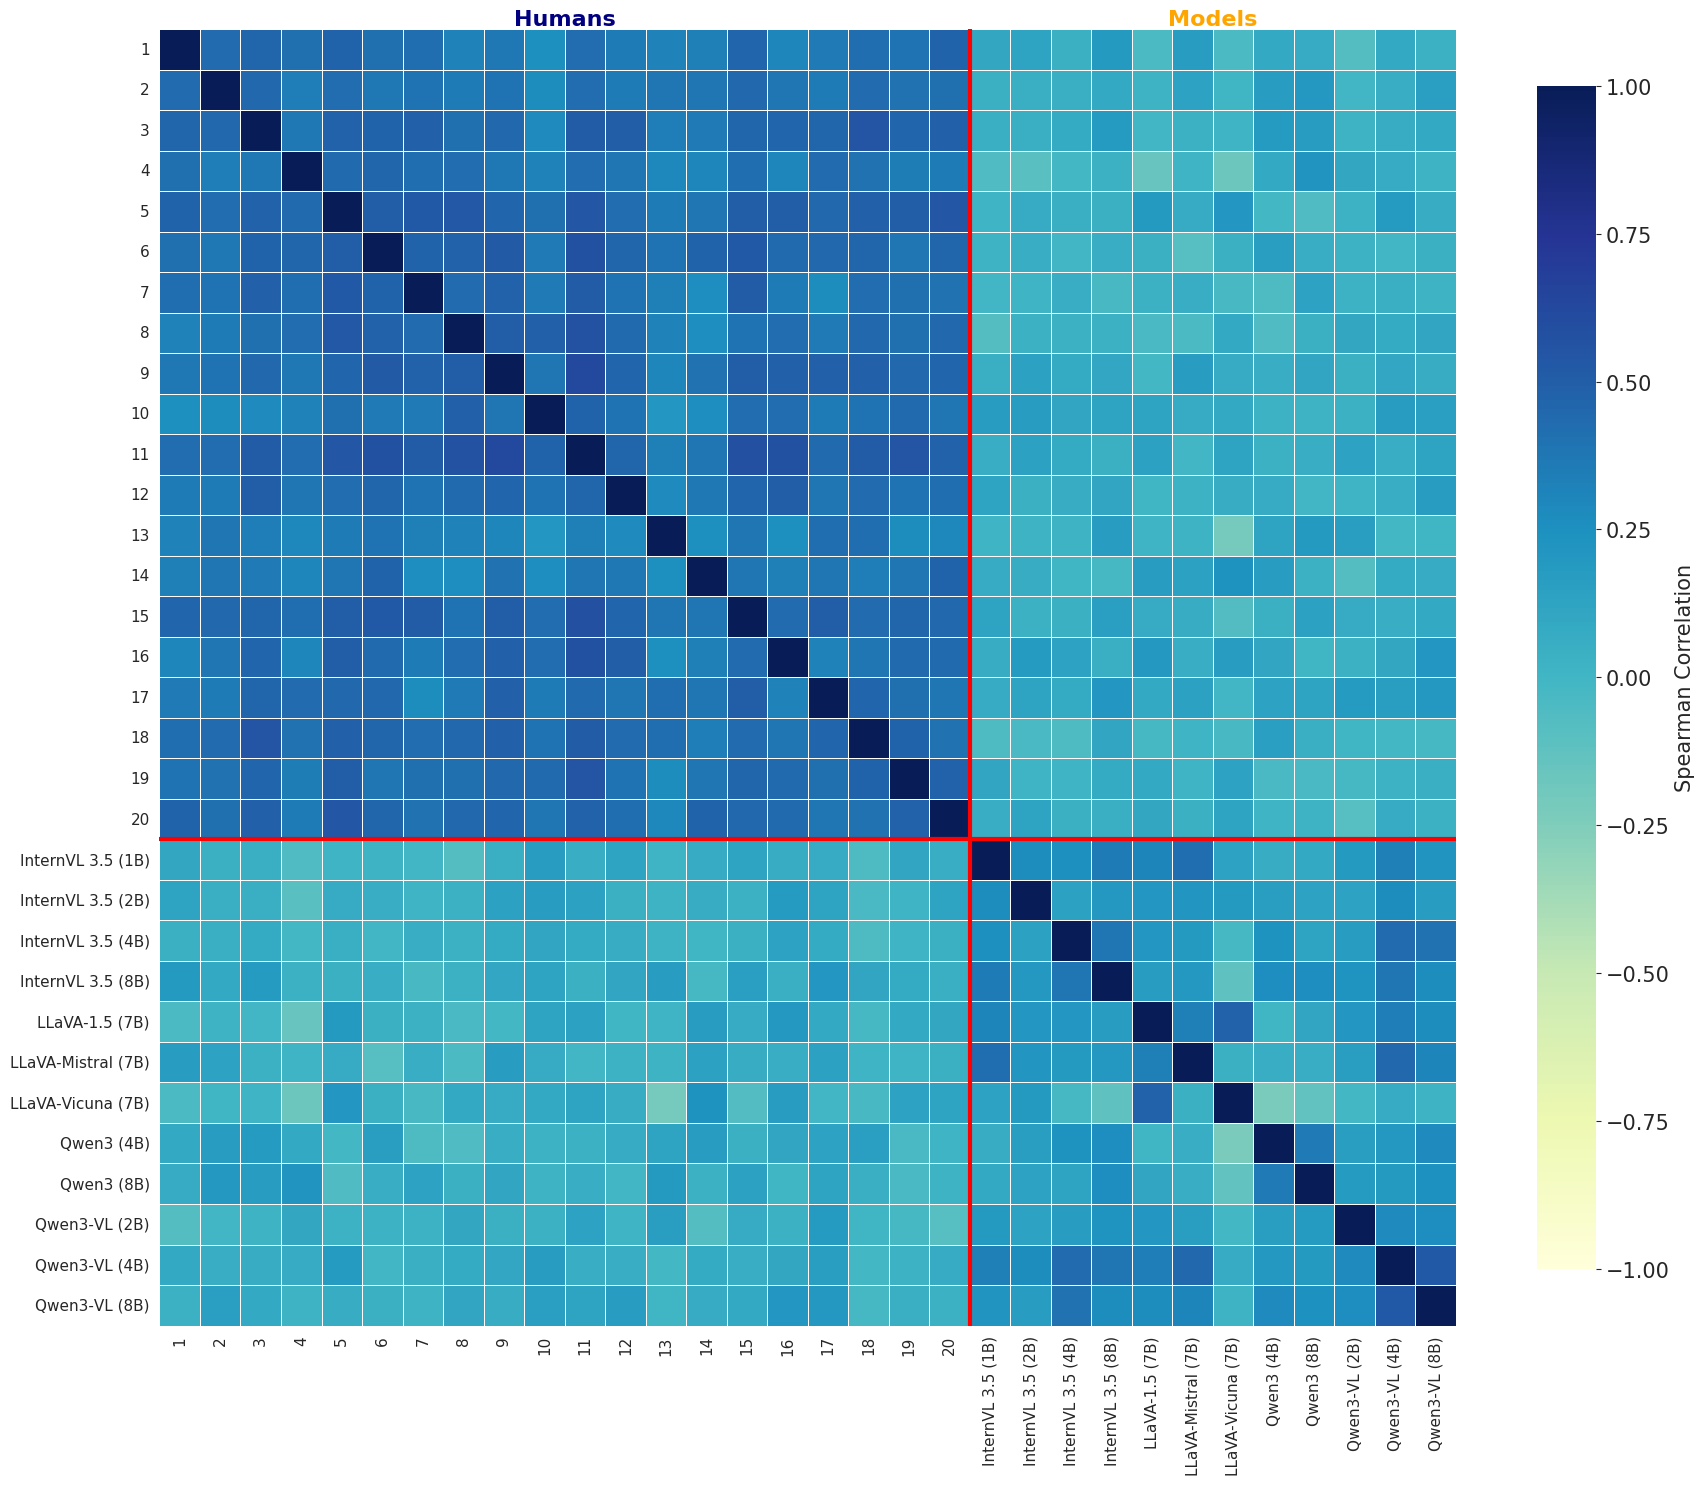

0.41736046794806747

In [88]:
res_HH, llm, model_corr, res_HM, res_MM = get_corr(
    mh, md, pids, correlation_type='ac1', metrics="correct", n_boot=0
)  
combined_matrix, participant_mapping = plot_correlation_heatmap(
    res_HH['corr_mat'], llm['corr_mat'], res_HM, res_MM,
    test_subjects=pids,
    save_path='ac1_score_heatmap.png'
) 
res_HH['mean_r']


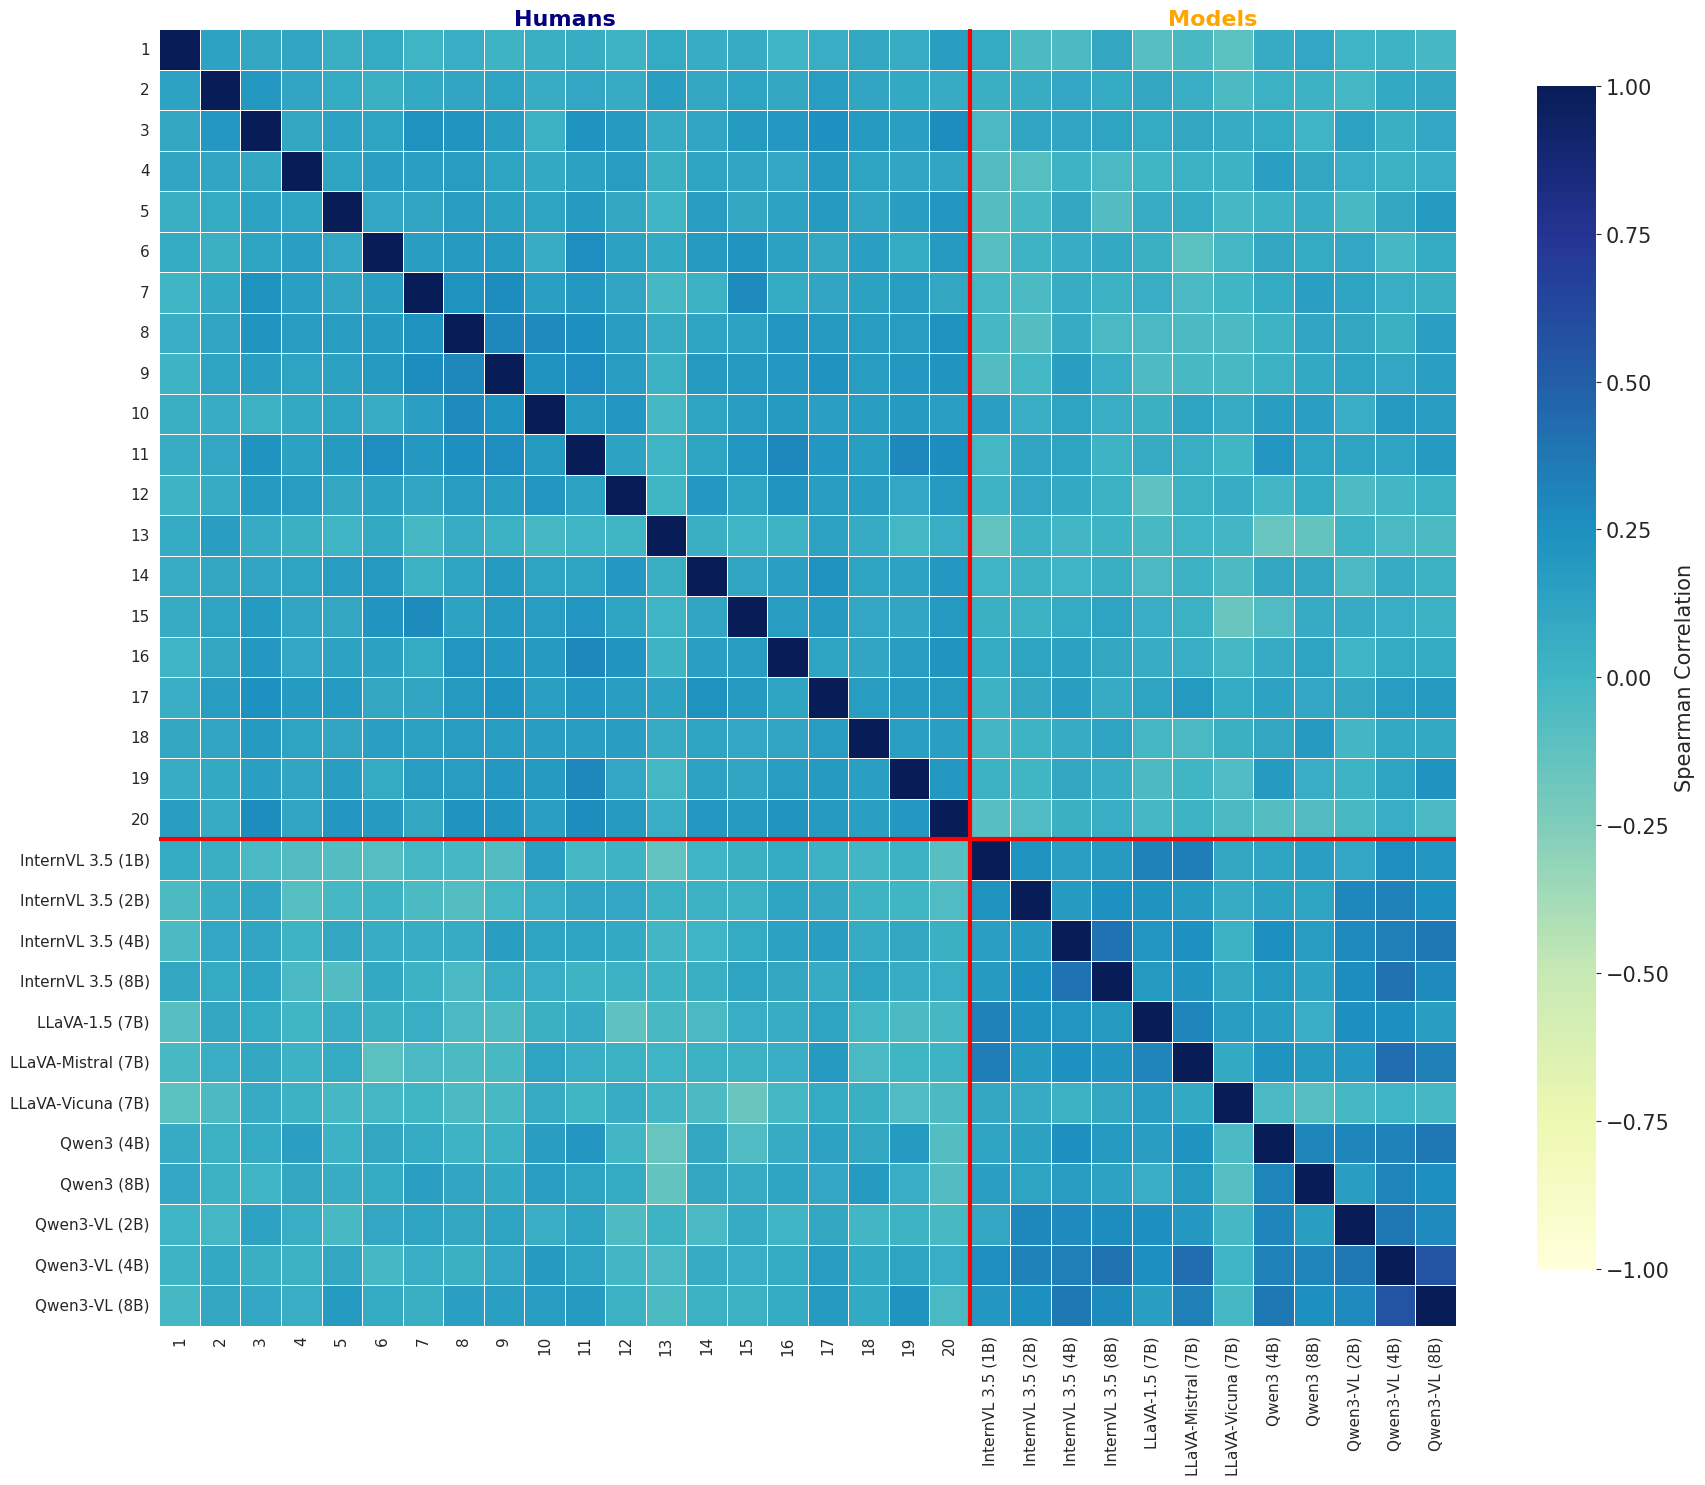

In [90]:
res_HH, llm, model_corr, res_HM, res_MM = get_corr(
    mh, md, pids, correlation_type='ac1', metrics="extracted_choice", n_boot=0
)  
combined_matrix, participant_mapping = plot_correlation_heatmap(
    res_HH['corr_mat'], llm['corr_mat'], res_HM, res_MM,
    test_subjects=pids,
    save_path='ac1_heatmap.png'
) 

In [ ]:
n_boot = 0
metrics = 'correct' 
human_acc = mm.human.pivot(
    index="question_id",
    columns="participant_id",
    values=metrics
)
test_model = mm.test_model
test_model = test_model[test_model['condition'] == ''] 
model_correct = test_model[test_model['condition'] == ''].groupby(['model', 'finetuned'])['correct'].mean().reset_index()   
model_correct = model_correct[~model_correct['model'].isin(['Qwen3 (4B)', 'Qwen3 (8B)'])] 
pcorr = pd.merge(model_corr, model_correct, how='left', on=['model', 'finetuned'])    
# Remove (n=15) from finetuned column values in pcorr DataFrame 
pcorr['finetuned'] = pcorr['finetuned'].str.replace(r"\s*\(n=15\)", "", regex=True)
pcorr.finetuned.unique()

array(['Pretrained', 'SFT-Blind MMStar', 'JS-Blind MMStar'], dtype=object)

# VQA 

In [3]:
vv = VQAResults()   
human_vqa = vv.human
# get_agreements(human_vqa, model_vqa, metrics="correct", n_boot=200) 
model_vqa = vv.model  # only the blind condition 
test_vqa = vv.test_model 
# human_vqa[human_vqa['question_id'] == 524577006 ].iloc[12][['processed_ans', 'correct', 'gt_answers']]  
model_vqa = vv.model
model_vqa = model_vqa[model_vqa['trained_dataset'] != 'MMStar']
model_vqa_pretrained = model_vqa[model_vqa['finetuned'] == 'Pretrained'] 

   Loading VQA annotations from /home/work/yuna/data/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
13 7
[]
[]


In [49]:
# from utils.corr import get_corr 

res_HH, llm, model_corr, res_HM, res_MM = get_corr(
    human_vqa, model_vqa, human_vqa.participant_id.unique(), metrics="correct", n_boot=0
) 


In [43]:

combined_matrix, participant_mapping = plot_correlation_heatmap(
    res_HH, llm, res_HM, res_MM,
    test_subjects=pids,
    save_path='correlation_heatmap.png'
) 

AttributeError: 'dict' object has no attribute 'index'

In [22]:
model_correct = vv.test_model[vv.test_model['condition'] == ''].groupby(['model', 'finetuned'])['correct'].mean().reset_index()   
pcorr = pd.merge(model_corr, model_correct, how='left', on=['model', 'finetuned'])   

In [23]:
pcorr.finetuned.unique()

array(['Pretrained', 'JS VQA (GT)', 'JS-Blind VQA (n=10)',
       'JS-Blind VQA (n=15)', 'SFT-Blind VQA', 'SFT-VQA'], dtype=object)

In [26]:
pcorr.rename(columns={'mean_human_model_corr': 'mean_r'}, inplace=True)

In [59]:
pcorr.blind.unique()

array(['Pretrained', 'Ground Truth', 'Blind (n=10)', 'Blind (n=15)',
       'Blind'], dtype=object)

In [62]:
def map_regime(finetuned):
    if finetuned == "Pretrained":
        return "Pretrained"

    if "Blind" in finetuned:
        if "n=15" in finetuned:
            return "Blind (n=15)"
        else: #  "n=10" in finetuned:
            return "Blind (n=10)"

    return "Ground Truth"


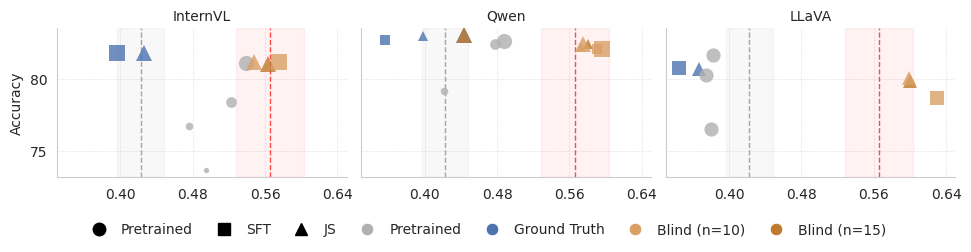

In [63]:
# from utils.plot_corr import plot_families_corr 
pcorr['strategy'] = pcorr['finetuned'].apply(lambda x: 'Pretrained' if x == 'Pretrained' else ('SFT' if 'SFT' in x else 'JS'))
pcorr["blind"] = pcorr["finetuned"].apply(map_regime)
plot_families_corr(pcorr, res_HH, llm)     # [pcorr['finetuned']!='JS-Blind VQA (n=10)'] 

In [58]:
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np 
from scipy.stats import t
from matplotlib.lines import Line2D

family_colors = {
    'InternVL': '#4C72B0',
    'LLaVA': '#DD8452',
    'Qwen': '#55A868'}  


regime_colors  = {
    "Ground Truth":  "#4C72B0",  # darker muted blue
    # "SFT-VQA":      "#8DA0CB",  # lighter blue
    # "Blind": "#D9A066",  
    "Blind (n=10)": "#D9A066",  
    "Blind (n=15)": "#C07A2D", 
    "Pretrained": "#B0B0B0"
}

regime_markers = {
    'Pretrained': 'o', 
    'JS': '^', 
    'SFT': 's',
}

def legend_handler(ax): 

    regime_handles = [
        Line2D(
            [0], [0],
            marker='o',
            linestyle='None',
            markerfacecolor=regime_colors[reg],
            markeredgecolor='white',
            markeredgewidth=0.6,
            markersize=9,
            label=reg,
        )
        for reg in regime_colors # ['JS VQA (GT)', 'SFT-VQA', 'JS-Blind VQA (n=15)', 'SFT-Blind VQA']
    ]

    leg1 = ax.legend(
        handles=regime_handles,
        # title="Training regime",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.2),
        ncol=4,
        fontsize=11,
        frameon=False,
    )

    ax.add_artist(leg1)  # ✅ CRITICAL

    marker_handles = [
        Line2D(
            [0], [0],
            marker=regime_markers[fam],
            linestyle='None',
            color='black',
            markersize=9,
            label=fam,
        )
        for fam in regime_markers
    ]

    ax.legend(
        handles=marker_handles,
        # title="Model family",
        loc="lower center",
        bbox_to_anchor=(1, 1),
        ncol=4,
        fontsize=11,
        frameon=False,
    )
    return ax
 
def plot_families_corr(model_corr, human, llm): 
    nrows, ncols = 1, 3
    fig, axes = plt.subplots(
        nrows, ncols, 
        figsize=(3.2 * ncols, 2 * nrows),
        constrained_layout=True,
        sharey=True,  # Share y axis
        # sharex=True, # if xshared else False,
        squeeze=False
    )
    ylabel, xlabel = "Accuracy", r"${\rho}$" 
    for ax in axes.flatten():
        ax.set_xlim(0.33, 0.65)
    axes_flat = axes.flatten() 

    for idx, fam in enumerate(model_corr.family.unique()) : 
        ax = axes_flat[idx] 
        ax.set_title(fam, fontsize=10)
        if idx == 0 : 
            ax.set_ylabel(ylabel, fontsize=10) 

        for label in (ax.get_xticklabels() + ax.get_yticklabels()):
            label.set_fontsize(10)
        if idx == 0 : 
            ax.set_ylabel(ylabel) 
        df = model_corr[model_corr['family'] == fam]
        
        for _, row in df.iterrows():
            color = regime_colors[row["blind"]]
            ax.errorbar(
                row["mean_r"],
                row["correct"],
                # xerr=row["std_corr"],
                fmt=regime_markers.get(row["strategy"], "o"),
                markerfacecolor=color,
                markeredgewidth=0.0,  # Remove edge on marker
                markeredgecolor=color,
                markersize=np.sqrt(row['model_size'] * 15),  # scale marker size
                capsize=2,
                zorder=3,
                ecolor=color,
                elinewidth=0,  # Slightly thinner error line for softness
                alpha=0.8,       # Make the error bars softer and more transparent
                errorevery=1,
            )

        ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=5))
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
        ax.set_axisbelow(True)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        ax.axvspan(llm['ci_2p5'], llm['ci_97p5'] , alpha=0.05, color='gray', zorder=1)
        ax.axvline(llm['mean_r'], color='gray', linestyle='--', linewidth=1, alpha=0.7, zorder=1, label='Qwen') 
    
        ax.axvspan(human['ci_2p5'], human['ci_97p5'] , alpha=0.05, color='red', zorder=1)
        ax.axvline(human['mean_r'], color='red', linestyle='--', linewidth=1, alpha=0.7, zorder=1, label='Humans') 

    handles = []
    labels = []

    # Collect unique regimes from both the 'strategy' and 'blind' columns for the current fam
    # Separate the regimes by row in the legend
    # Get unique regimes for each row label
    regimes_strategy = list(df["strategy"].unique())
    regimes_blind = list(df["blind"].unique()) if "blind" in df.columns else []

        # ---- Legends (global, consistent across families) ----
    regime_handles = [
        Line2D([0], [0],
               marker='o', linestyle='None',
               markerfacecolor=regime_colors[k],
               markeredgecolor='white', markeredgewidth=0.6,
               markersize=9, label=k)
        for k in ["Pretrained", "Ground Truth", "Blind (n=10)", "Blind (n=15)", "Blind"]
        if k in regime_colors
    ]

    marker_handles = [
        Line2D([0], [0],
               marker=regime_markers[k], linestyle='None',
               color='black', markersize=9, label=k)
        for k in ["Pretrained", "SFT", "JS"]
        if k in regime_markers
    ]
    combined_handles = marker_handles + regime_handles 

    fig.legend(
        handles=combined_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.22),
        ncol=len(combined_handles),
        frameon=False,
        fontsize=10,
        columnspacing=1.2,
        handletextpad=0.6
    )

    plt.show() 


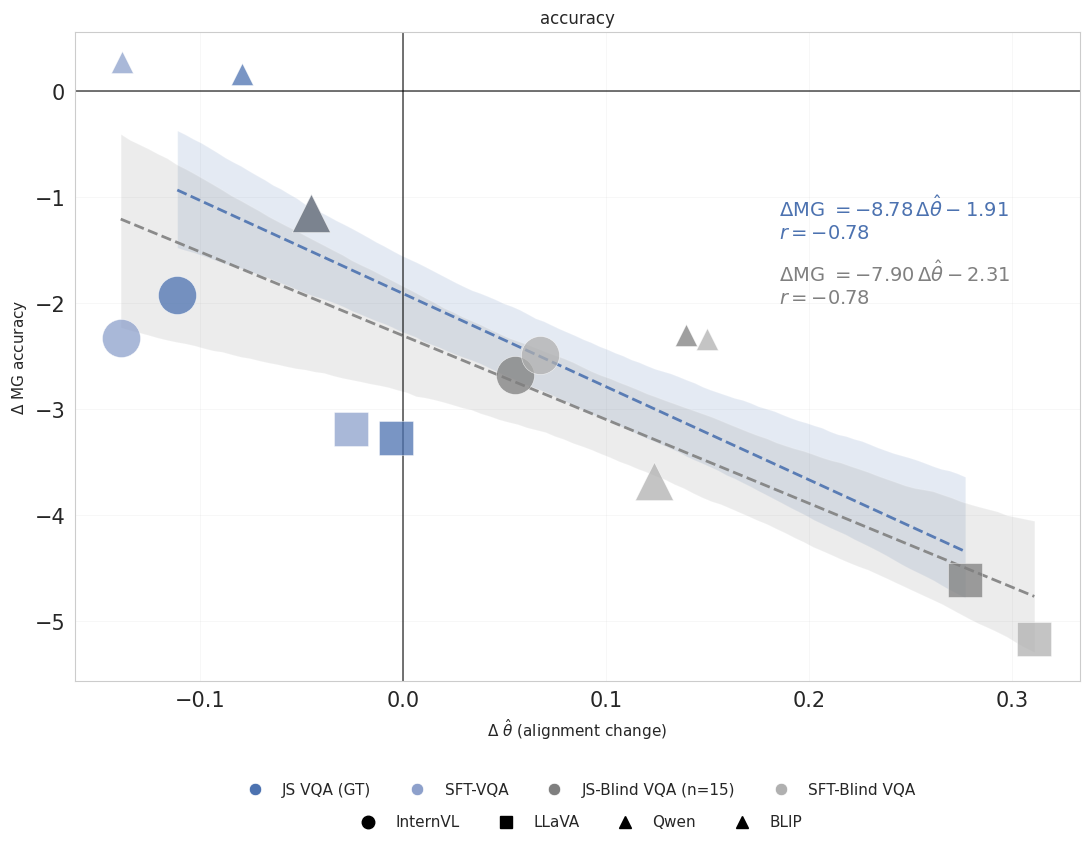

In [655]:
x_col = "theta_hat"
y_col = "MG_acc" 
delta_df = get_delta_df(pcorr[pcorr['dataset'] == 'VQA'])

scatterplot_delta_alignment_vs_mg(
    delta_df,
    title = 'accuracy',
    regression_stats = get_stats(delta_df), 
    EQ_POS= {
    "JS":  (0.7, 0.75),
    "SFT": (0.7, 0.65),
    }, 
    colors= regime_colors,          # keyed by finetuned regime
    markers= family_markers ,
    figsize=(11,8) ) 